# Importing all modules we need

In [1]:
import math

import pandas as pd
import os

# Loading all files we will need later on


In [2]:
path_fitts = os.path.join('results', 'fitts')
path_steering = os.path.join('results', 'steering')

files_fitts = [file for file in os.listdir(path_fitts) if file.endswith('.csv')]
files_steering = [file for file in os.listdir(path_steering) if file.endswith('.csv')]

dfs_fitts = []

for file in files_fitts:
    path = os.path.join(path_fitts, file)
    dfs_fitts.append(pd.read_csv(path))

df_fitts = pd.concat(dfs_fitts, ignore_index=True)

dfs_steering = []

for file in files_steering:
    path = os.path.join(path_steering, file)
    dfs_steering.append(pd.read_csv(path))

df_steering = pd.concat(dfs_steering, ignore_index=True)

In [3]:
print(df_fitts)

      iteration part_id input_method  delay  num_targets  radius  distance  \
0             0  hector        mouse      0            8      25       350   
1             0  hector        mouse      0            8      25       350   
2             0  hector        mouse      0            8      25       350   
3             0  hector        mouse      0            8      25       350   
4             0  hector        mouse      0            8      25       350   
...         ...     ...          ...    ...          ...     ...       ...   
3004          2     pat     touchpad      0            8      55       550   
3005          2     pat     touchpad      0            8      55       550   
3006          2     pat     touchpad      0            8      55       550   
3007          2     pat     touchpad      0            8      55       550   
3008          2     pat     touchpad      0            8      55       550   

      target_id  hit      timestamp  
0             6    1  178

In [4]:
df_steering

,iteration,part_id,input_method,delay,width,distance,errors,start_time,end_time
0,1,hector,mouse,0,100,400,0,1782843271943,1782843272404
1,2,hector,mouse,0,100,400,0,1782843274286,1782843274689
2,3,hector,mouse,0,100,400,0,1782843276454,1782843276960
3,1,hector,mouse,0,100,600,0,1782843252350,1782843253259
4,2,hector,mouse,0,100,600,0,1782843255863,1782843256922
...,...,...,...,...,...,...,...,...,...
319,2,pat,touchpad,0,60,600,0,1782853088635,1782853090651
320,3,pat,touchpad,0,60,600,0,1782853092232,1782853096203
321,1,pat,touchpad,0,60,800,0,1782853135162,1782853138349
322,2,pat,touchpad,0,60,800,1,1782853139437,1782853142016


In [5]:
fitts_runs_df = (
    df_fitts
    .groupby(
        [
            "part_id",
            "input_method",
            "delay",
            "radius",
            "distance",
            "iteration",
        ],
        as_index=False,
    )
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        num_clicks=("hit", "count"),
        num_hits = ("hit", "sum"),
        num_targets=("target_id", "count"),
    )
)

fitts_runs_df["duration_ms"] = (
    fitts_runs_df["end_time"] - fitts_runs_df["start_time"]
)

fitts_runs_df['accuracy'] = (
    fitts_runs_df['num_hits'] / fitts_runs_df['num_targets']
)

print(fitts_runs_df)

    part_id input_method  delay  radius  distance  iteration     start_time  \
0    hector        mouse      0      25       350          0  1782833728863   
1    hector        mouse      0      25       350          1  1782833736212   
2    hector        mouse      0      25       350          2  1782833744422   
3    hector        mouse      0      25       450          0  1782833545948   
4    hector        mouse      0      25       450          1  1782833555915   
..      ...          ...    ...     ...       ...        ...            ...   
319     pat     touchpad      0      55       450          1  1782851776244   
320     pat     touchpad      0      55       450          2  1782851784875   
321     pat     touchpad      0      55       550          0  1782851822350   
322     pat     touchpad      0      55       550          1  1782851830505   
323     pat     touchpad      0      55       550          2  1782851838576   

          end_time  num_clicks  num_hits  num_targe

In [8]:
import numpy as np

mean_df_fitts = (
    fitts_runs_df.groupby(
        ['part_id', 'input_method', 'delay', 'radius', 'distance'],
        as_index=False
    ).agg(
        mean_duration=("duration_ms", "mean"),
        mean_accuracy=("accuracy", "mean"),
    )
)

# Mean duration in seconds
mean_df_fitts["mean_duration_seconds"] = (
    mean_df_fitts["mean_duration"] / 1000
).round(2)

mean_df_fitts["mean_movement_time"] = (
    mean_df_fitts["mean_duration_seconds"] / 8
)

# Target width (diameter)
mean_df_fitts["width"] = mean_df_fitts["radius"] * 2

# Shannon Index of Difficulty (bits)
mean_df_fitts["ID"] = np.log2(
    mean_df_fitts["distance"] / mean_df_fitts["width"] + 1
).round(2)

# Throughput (bits/second)
mean_df_fitts["throughput"] = (
    mean_df_fitts["ID"] / mean_df_fitts["mean_movement_time"]
).round(2)

# Optional
mean_df_fitts["no_errors"] = mean_df_fitts["mean_accuracy"] == 1

In [9]:
print(mean_df_fitts)

    part_id input_method  delay  radius  distance  mean_duration  \
0    hector        mouse      0      25       350    5761.666667   
1    hector        mouse      0      25       450    6969.333333   
2    hector        mouse      0      25       550    6795.333333   
3    hector        mouse      0      40       350    4888.333333   
4    hector        mouse      0      40       450    4926.666667   
..      ...          ...    ...     ...       ...            ...   
103     pat     touchpad      0      40       450    6268.333333   
104     pat     touchpad      0      40       550    7508.000000   
105     pat     touchpad      0      55       350    6966.666667   
106     pat     touchpad      0      55       450    7241.333333   
107     pat     touchpad      0      55       550    6659.333333   

     mean_accuracy  mean_duration_seconds  mean_movement_time  width    ID  \
0         1.000000                   5.76             0.72000     50  3.00   
1         1.000000         

In [8]:
mean_fitts_combined = mean_df_fitts.groupby(
    ['part_id', 'input_method', 'delay'], as_index=False
).agg(
    total_mean_duration=("mean_duration_seconds", "mean"),
    total_mean_accuracy=("mean_accuracy", "mean"),
    total_no_errors=("no_errors", "sum")
)

print(mean_fitts_combined)

   part_id input_method  delay  total_mean_duration  total_mean_accuracy  \
0   hector        mouse      0             5.465556             0.995885   
1   hector        mouse    150             6.094444             0.987654   
2   hector         pose      0            28.897778             0.796857   
3   hector     touchpad      0             6.812222             0.983539   
4  martina        mouse      0             3.881111             0.963786   
5  martina        mouse    150             5.663333             0.938047   
6  martina         pose      0            14.146667             0.674068   
7  martina     touchpad      0             4.504444             0.984362   

   total_no_errors  
0                8  
1                6  
2                0  
3                5  
4                4  
5                1  
6                0  
7                6  


In [9]:
mean_fitts_final = mean_fitts_combined.groupby(
    ['input_method', 'delay'], as_index=False
).agg(
    mean_duration=("total_mean_duration", "mean"),
    mean_accuracy=("total_mean_accuracy", "mean"),
)
mean_fitts_final['mean_duration'] = mean_fitts_final['mean_duration'].round(2)
print(mean_fitts_final)

  input_method  delay  mean_duration  mean_accuracy
0        mouse      0           4.67       0.979835
1        mouse    150           5.88       0.962851
2         pose      0          21.52       0.735463
3     touchpad      0           5.66       0.983951


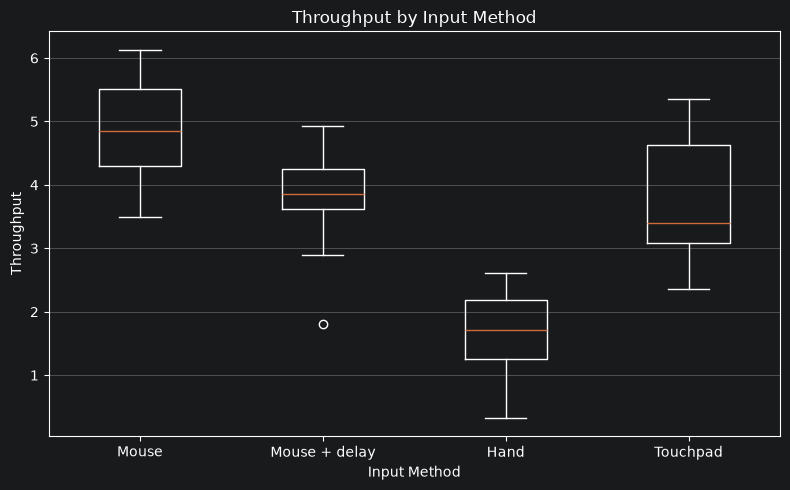

In [13]:
import matplotlib.pyplot as plt

plot_data = {
    "Mouse": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] == 0)
    ]["throughput"],

    "Mouse + delay": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] > 0)
    ]["throughput"],

    "Hand": mean_df_fitts[
        mean_df_fitts["input_method"] == "pose"
    ]["throughput"],

    "Touchpad": mean_df_fitts[
        mean_df_fitts["input_method"] == "touchpad"
    ]["throughput"],
}

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data.values(), tick_labels=plot_data.keys())
plt.title("Throughput by Input Method")
plt.xlabel("Input Method")
plt.ylabel("Throughput")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig('results/fitts_tp.pdf')
plt.show()

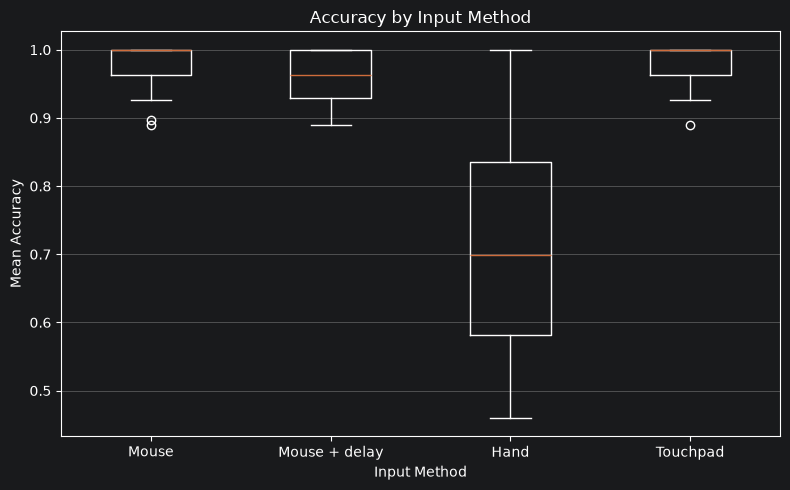

In [14]:
import matplotlib.pyplot as plt

plot_data = {
    "Mouse": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] == 0)
    ]["mean_accuracy"],

    "Mouse + delay": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] > 0)
    ]["mean_accuracy"],

    "Hand": mean_df_fitts[
        mean_df_fitts["input_method"] == "pose"
    ]["mean_accuracy"],

    "Touchpad": mean_df_fitts[
        mean_df_fitts["input_method"] == "touchpad"
    ]["mean_accuracy"],
}

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data.values(), tick_labels=plot_data.keys())
plt.title("Accuracy by Input Method")
plt.xlabel("Input Method")
plt.ylabel("Mean Accuracy")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig('results/fitts_ac.pdf')
plt.show()

In [12]:
print(df_steering)

     iteration  part_id input_method  delay  width  distance  errors  \
0            1   hector        mouse      0    100       400       0   
1            2   hector        mouse      0    100       400       0   
2            3   hector        mouse      0    100       400       0   
3            1   hector        mouse      0    100       600       0   
4            2   hector        mouse      0    100       600       0   
..         ...      ...          ...    ...    ...       ...     ...   
211          2  martina     touchpad      0     60       600       2   
212          3  martina     touchpad      0     60       600       0   
213          1  martina     touchpad      0     60       800       0   
214          2  martina     touchpad      0     60       800       0   
215          3  martina     touchpad      0     60       800       0   

        start_time       end_time  
0    1782843271943  1782843272404  
1    1782843274286  1782843274689  
2    1782843276454  1782843

In [13]:
df_steering['duration'] = ((df_steering['end_time'] - df_steering['start_time']) / 1000).round(2)

df_steering_iterations = df_steering.groupby(
    ['part_id', 'input_method', 'delay', 'width', 'distance'], as_index=False
).agg(
    mean_duration=("duration", "mean"),
    total_errors=('errors', 'sum')
)

df_steering_iterations['error_rate'] = df_steering_iterations['total_errors'] / 3


In [14]:
print(df_steering_iterations)

    part_id input_method  delay  width  distance  mean_duration  total_errors  \
0    hector        mouse      0     60       400       0.430000             1   
1    hector        mouse      0     60       600       0.776667             0   
2    hector        mouse      0     60       800       0.973333             0   
3    hector        mouse      0    100       400       0.456667             0   
4    hector        mouse      0    100       600       0.936667             0   
..      ...          ...    ...    ...       ...            ...           ...   
67  martina     touchpad      0    100       600       0.646667             0   
68  martina     touchpad      0    100       800       1.023333             1   
69  martina     touchpad      0    140       400       0.340000             0   
70  martina     touchpad      0    140       600       0.586667             0   
71  martina     touchpad      0    140       800       0.463333             0   

    error_rate  
0     0.33

In [15]:
df_steering_combined = df_steering_iterations.groupby(
    ['input_method', 'delay'], as_index=False
).agg(
    total_errors=("total_errors", "sum"),
    mean_error_rate=("error_rate", "mean"),
    mean_duration=('mean_duration', 'mean')
)

In [16]:
print(df_steering_combined)

  input_method  delay  total_errors  mean_error_rate  mean_duration
0        mouse      0             2         0.037037       0.706852
1        mouse    150             2         0.037037       0.848519
2         pose      0             4         0.074074       1.400926
3     touchpad      0             9         0.166667       0.708333


In [17]:
df_steering_participants = df_steering_iterations.groupby(
    ['part_id', 'input_method', 'delay'], as_index=False
).agg(
    total_errors=("total_errors", "sum"),
    mean_error_rate=("error_rate", "mean"),
    mean_duration=('mean_duration', 'mean')
)

In [18]:
print(df_steering_participants)

   part_id input_method  delay  total_errors  mean_error_rate  mean_duration
0   hector        mouse      0             1         0.037037       0.638889
1   hector        mouse    150             2         0.074074       0.911852
2   hector         pose      0             3         0.111111       1.145556
3   hector     touchpad      0             5         0.185185       0.719259
4  martina        mouse      0             1         0.037037       0.774815
5  martina        mouse    150             0         0.000000       0.785185
6  martina         pose      0             1         0.037037       1.656296
7  martina     touchpad      0             4         0.148148       0.697407


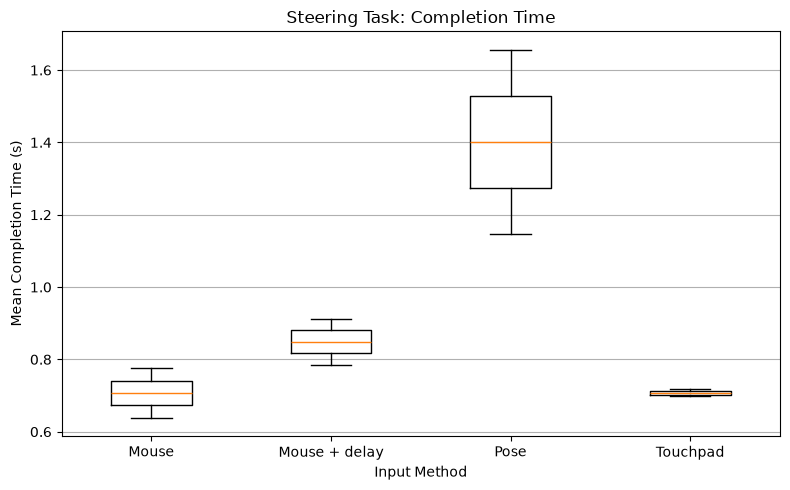

In [19]:
import matplotlib.pyplot as plt

plot_data = {
    "Mouse": df_steering_participants[
        (df_steering_participants["input_method"] == "mouse") &
        (df_steering_participants["delay"] == 0)
    ]["mean_duration"],

    "Mouse + delay": df_steering_participants[
        (df_steering_participants["input_method"] == "mouse") &
        (df_steering_participants["delay"] > 0)
    ]["mean_duration"],

    "Pose": df_steering_participants[
        df_steering_participants["input_method"] == "pose"
    ]["mean_duration"],

    "Touchpad": df_steering_participants[
        df_steering_participants["input_method"] == "touchpad"
    ]["mean_duration"],
}

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data.values(), tick_labels=plot_data.keys())

plt.title("Steering Task: Completion Time")
plt.xlabel("Input Method")
plt.ylabel("Mean Completion Time (s)")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

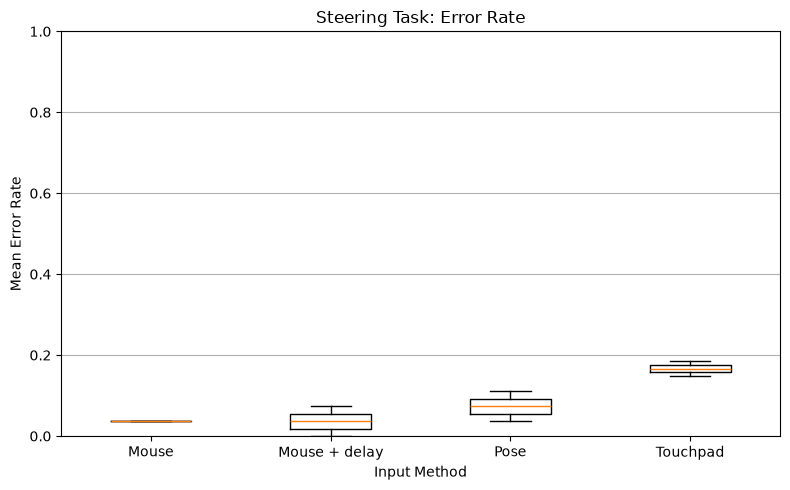

In [20]:
import matplotlib.pyplot as plt

plot_data = {
    "Mouse": df_steering_participants[
        (df_steering_participants["input_method"] == "mouse") &
        (df_steering_participants["delay"] == 0)
    ]["mean_error_rate"],

    "Mouse + delay": df_steering_participants[
        (df_steering_participants["input_method"] == "mouse") &
        (df_steering_participants["delay"] > 0)
    ]["mean_error_rate"],

    "Pose": df_steering_participants[
        df_steering_participants["input_method"] == "pose"
    ]["mean_error_rate"],

    "Touchpad": df_steering_participants[
        df_steering_participants["input_method"] == "touchpad"
    ]["mean_error_rate"],
}

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data.values(), tick_labels=plot_data.keys())

plt.title("Steering Task: Error Rate")
plt.xlabel("Input Method")
plt.ylabel("Mean Error Rate")
plt.ylim(0, 1)
plt.grid(axis="y")

plt.tight_layout()
plt.show()